In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import numpy as np
import os
import zipfile
import cv2
import matplotlib.pyplot as plt


In [ ]:
zip_path = '/content/dataset2.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'File berhasil diekstrak ke {extract_path}')

File berhasil diekstrak ke /content/


In [ ]:
def canny_edge_detection(image_array):
    gray_image = cv2.cvtColor(image_array.astype('float32'), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(np.uint8(gray_image*255), threshold1=100, threshold2=200)
    return edges

In [ ]:
def show_images(original_img, segmented_img):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Gambar asli")
    axes[0].axis("off")

    axes[1].imshow(segmented_img, cmap='gray')
    axes[1].set_title("Canny Edge Segmentation")
    axes[1].axis("off")

    plt.show()

In [ ]:
image_dir = '/content/dataset2'

images = []
labels = []

data_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        # Augmentasi gambar
        img_array = np.expand_dims(img_array, axis=0)
        augmented_images = data_gen.flow(img_array, batch_size=1)

        for _ in range(3):
            aug_img = next(augmented_images)[0]
            images.append(aug_img)
            labels.append(label)

        images.append(img_array[0])
        labels.append(label)

X = np.array(images)
y = np.array(labels)

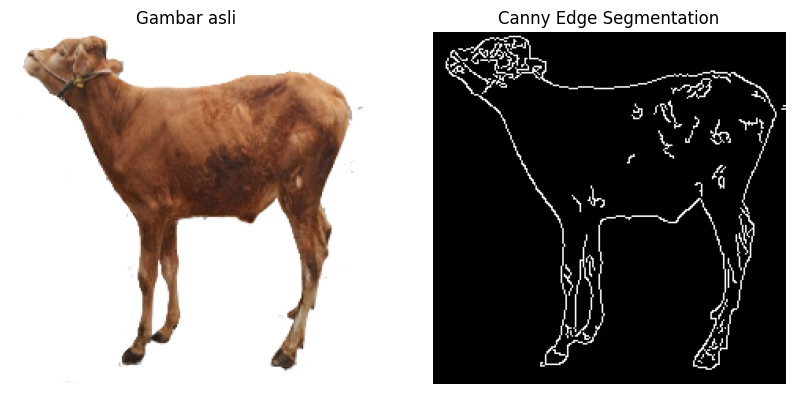

In [ ]:
def select_image_by_path(image_path):
    if os.path.exists(image_path):
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        return img_array
    else:
        print(f"Gambar dengan path {image_path} tidak ditemukan!")
        return None

image_path = '/content/dataset2/180.jpg'
selected_image = select_image_by_path(image_path)

if selected_image is not None:
    segmented_image = canny_edge_detection(selected_image)
    show_images(selected_image, segmented_image)

In [ ]:
import tensorflow as tf

# Load MobileNetV2 sebagai base model (tanpa top layer)
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',  # Menggunakan bobot pretrained dari ImageNet
    include_top=False,   # Menghapus fully connected layer default
    input_shape=(224, 224, 3)
)

# Bekukan semua layer pada base model agar tidak dilatih ulang
base_model.trainable = False

# Bangun model dengan lapisan tambahan
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),  # Mengurangi dimensi fitur ke satu vektor
    tf.keras.layers.Dense(128, activation='relu'),  # Lapisan tambahan untuk regresi
    tf.keras.layers.Dropout(0.3),  # Dropout untuk mengurangi overfitting
    tf.keras.layers.Dense(1, activation='linear')  # Output 1 neuron untuk regresi bobot
])

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',  # Mean Squared Error untuk regresi
              metrics=['mae'])  # Mean Absolute Error untuk evaluasi

# Menampilkan arsitektur model
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import tensorflow as tf
import time

def rmse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Konversi y_true ke float32
    return tf.sqrt(tf.keras.backend.mean(tf.square(y_true - y_pred)))

# Compile model dengan RMSE
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', rmse]
)

# Callback untuk menyimpan model terbaik
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Mulai hitung waktu training
start_time = time.time()

# Training model
history = model.fit(
    X, y.astype('float32'),  # Pastikan y bertipe float32
    epochs=750,
    batch_size=32,
    callbacks=[checkpoint]
)

# Selesai hitung waktu training
end_time = time.time()
training_time = end_time - start_time
print(f"Waktu training: {training_time:.2f} detik")


Epoch 1/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - loss: 223197.4688 - mae: 420.6448 - rmse: 471.7712
Epoch 1: loss improved from inf to 238021.92188, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 228138.9531 - mae: 425.7790 - rmse: 476.8367   
Epoch 2/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - loss: 244740.3281 - mae: 440.2770 - rmse: 494.3021
Epoch 2: loss improved from 238021.92188 to 233082.67188, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 981ms/step - loss: 240854.4375 - mae: 436.8962 - rmse: 490.2680
Epoch 3/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 226782.6562 - mae: 424.2458 - rmse: 476.2818
Epoch 3: loss improved from 233082.67188 to 228249.95312, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 227271.7656 - mae: 424.3079 - rmse: 476.7416
Epoch 4/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - loss: 234264.1562 - mae: 429.2213 - rmse: 483.6487
Epoch 4: loss improved from 228249.95312 to 223442.25000, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 230656.8594 - mae: 425.7003 - rmse: 479.7805   
Epoch 5/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - loss: 231030.8125 - mae: 415.6947 - rmse: 480.0242
Epoch 5: loss improved from 223442.25000 to 218166.79688, saving model to best_model.h5


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 868ms/step - loss: 1305.0359 - mae: 26.3978 - rmse: 311.9441
Epoch 609/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - loss: 2358.3760 - mae: 34.6249 - rmse: 313.0013
Epoch 609: loss did not improve from 1489.94043
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 867ms/step - loss: 2370.3992 - mae: 35.0836 - rmse: 314.0948
Epoch 610/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - loss: 3549.9692 - mae: 41.2049 - rmse: 313.4656
Epoch 610: loss did not improve from 1489.94043
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step - loss: 3500.2654 - mae: 40.8313 - rmse: 312.8665
Epoch 611/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - loss: 2395.9170 - mae: 36.8727 - rmse: 293.2848
Epoch 611: loss did not improve from 1489.94043
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step - loss: 2486.7815 - mae: 37.0744 - rmse: 299.4880
Epoch 612/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - loss: 2286.8232 - mae: 36.0800 - rmse: 309.1354
Epoch 612: loss did not improve from 1489.94043
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 711ms/step -

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 910ms/step - loss: 1277.2861 - mae: 28.6738 - rmse: 308.5282
Epoch 667/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - loss: 1322.8206 - mae: 29.1036 - rmse: 309.7767
Epoch 667: loss improved from 1387.92114 to 1308.49182, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 897ms/step - loss: 1318.0443 - mae: 28.7544 - rmse: 308.3407
Epoch 668/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - loss: 2068.9746 - mae: 33.6351 - rmse: 318.1170
Epoch 668: loss did not improve from 1308.49182
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step - loss: 2198.4204 - mae: 34.7472 - rmse: 313.0595
Epoch 669/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 1583.8345 - mae: 31.6476 - rmse: 321.4302
Epoch 669: loss did not improve from 1308.49182
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step - loss: 1564.2605 - mae: 31.5665 - rmse: 318.9792
Epoch 670/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - loss: 1074.9514 - mae: 23.7708 - rmse: 324.7918
Epoch 670: loss improved from 1308.49182 to 1214.59277, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 877ms/step - loss: 1121.4985 - mae: 24.2314 - rmse: 318.1748
Epoch 671/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - loss: 2323.1448 - mae: 36.2110 - rmse: 316.3557
Epoch 671: loss did not improve from 1214.59277
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step - loss: 2201.7744 - mae: 35.2505 - rmse: 310.2475
Epoch 672/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - loss: 1391.2731 - mae: 27.8201 - rmse: 288.3752
Epoch 672: loss did not improve from 1214.59277
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 719ms/step - loss: 1442.5597 - mae: 28.2860 - rmse: 293.9289
Epoch 673/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - loss: 3354.4536 - mae: 43.4559 - rmse: 305.5385
Epoch 673: loss did not improve from 1214.59277
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step - loss: 3358.7024 - mae: 43.2371 - rmse: 306.7774
Epoch 674/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - loss: 2286.1328 - mae: 36.9795 - rmse: 282.9386
Epoch 674: loss did not improve from 1214.59277
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 723ms/step -

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 885ms/step - loss: 1310.3420 - mae: 27.5338 - rmse: 305.4679
Epoch 733/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - loss: 3026.7219 - mae: 37.0110 - rmse: 308.1862
Epoch 733: loss did not improve from 1146.16052
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step - loss: 3063.4202 - mae: 37.4282 - rmse: 308.7629
Epoch 734/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2070.4180 - mae: 31.8199 - rmse: 272.9232   
Epoch 734: loss did not improve from 1146.16052
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 2263.1958 - mae: 32.7822 - rmse: 284.2295
Epoch 735/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - loss: 1345.9862 - mae: 29.1744 - rmse: 319.9645
Epoch 735: loss did not improve from 1146.16052
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - loss: 1303.0453 - mae: 28.4312 - rmse: 316.4724
Epoch 736/750
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - loss: 1816.0574 - mae: 33.1169 - rmse: 290.4551
Epoch 736: loss did not improve from 1146.16052
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 717ms/step - lo

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


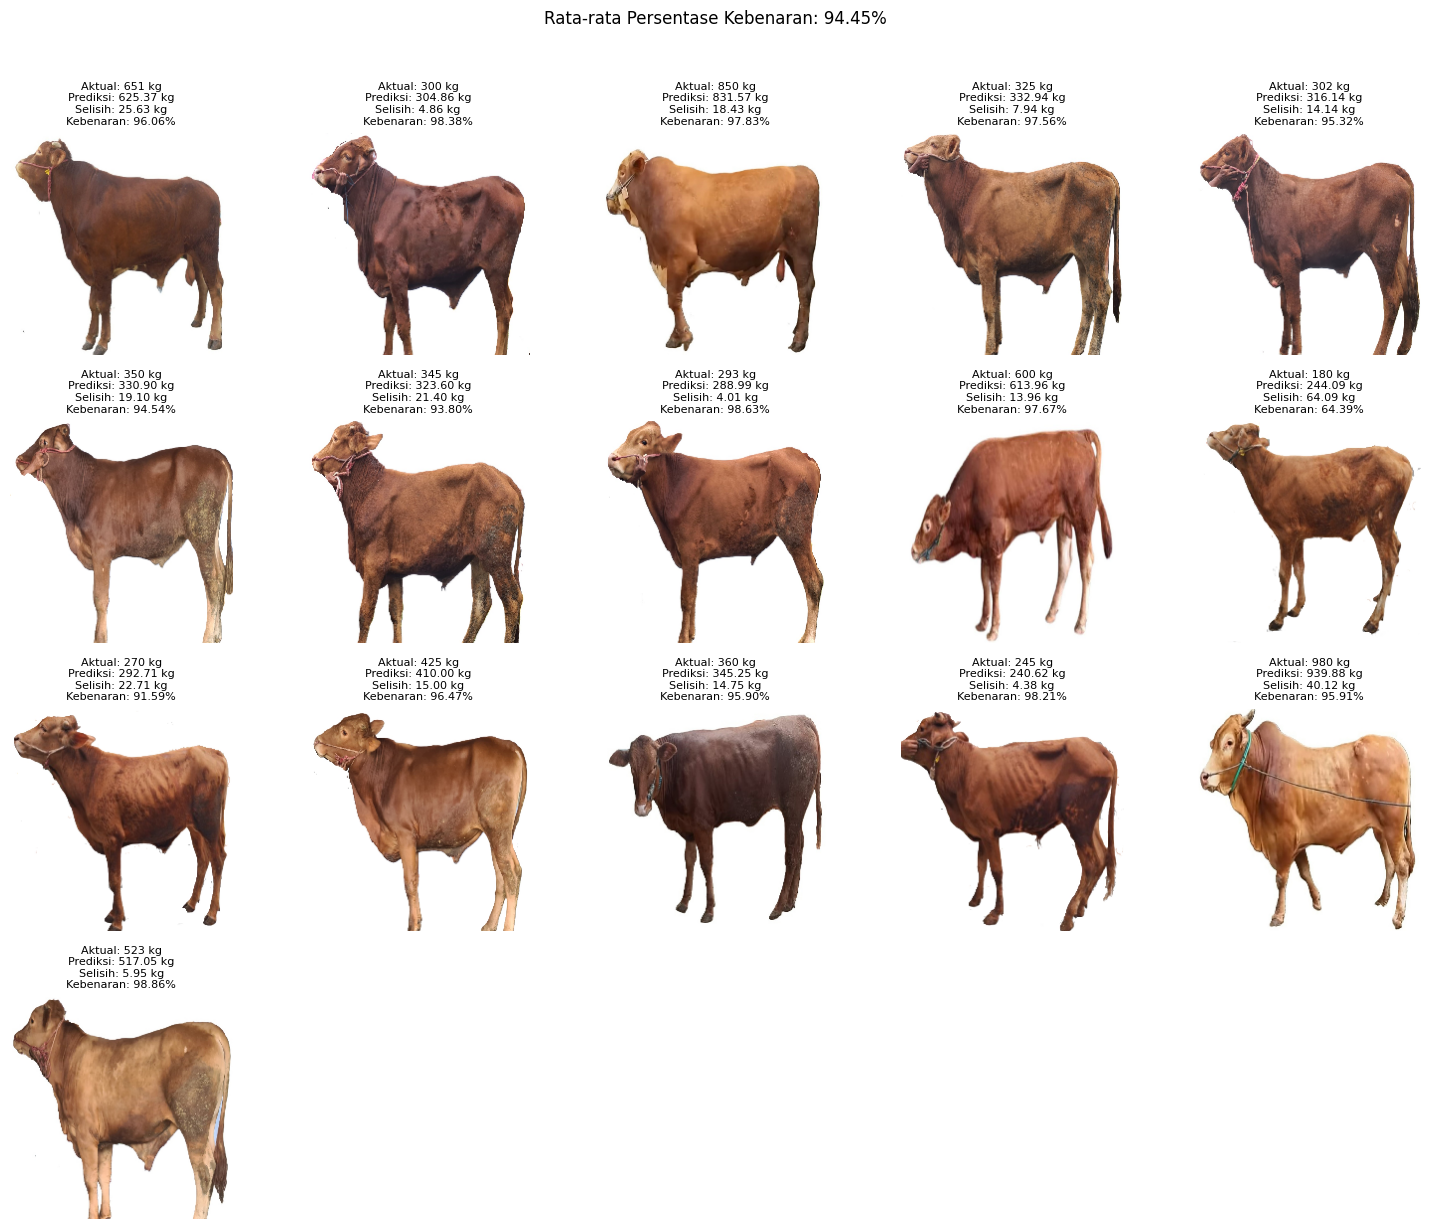

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/dataset2.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/dataset2'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step


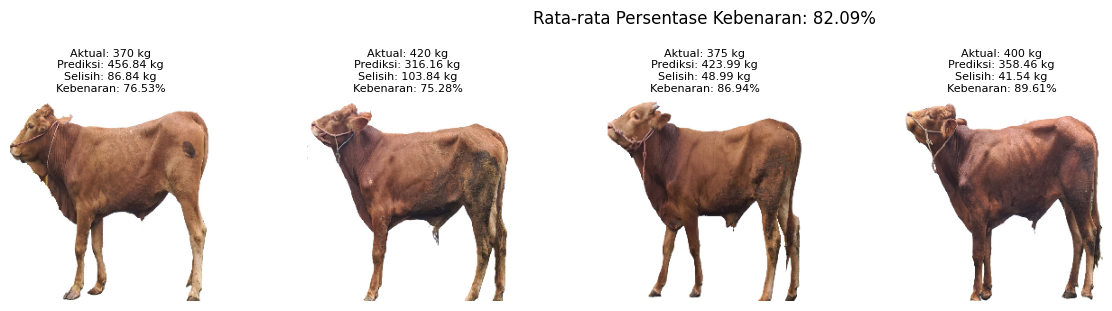

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        # Memuat gambar
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        label = int(filename.split('.')[0])
        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)

num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

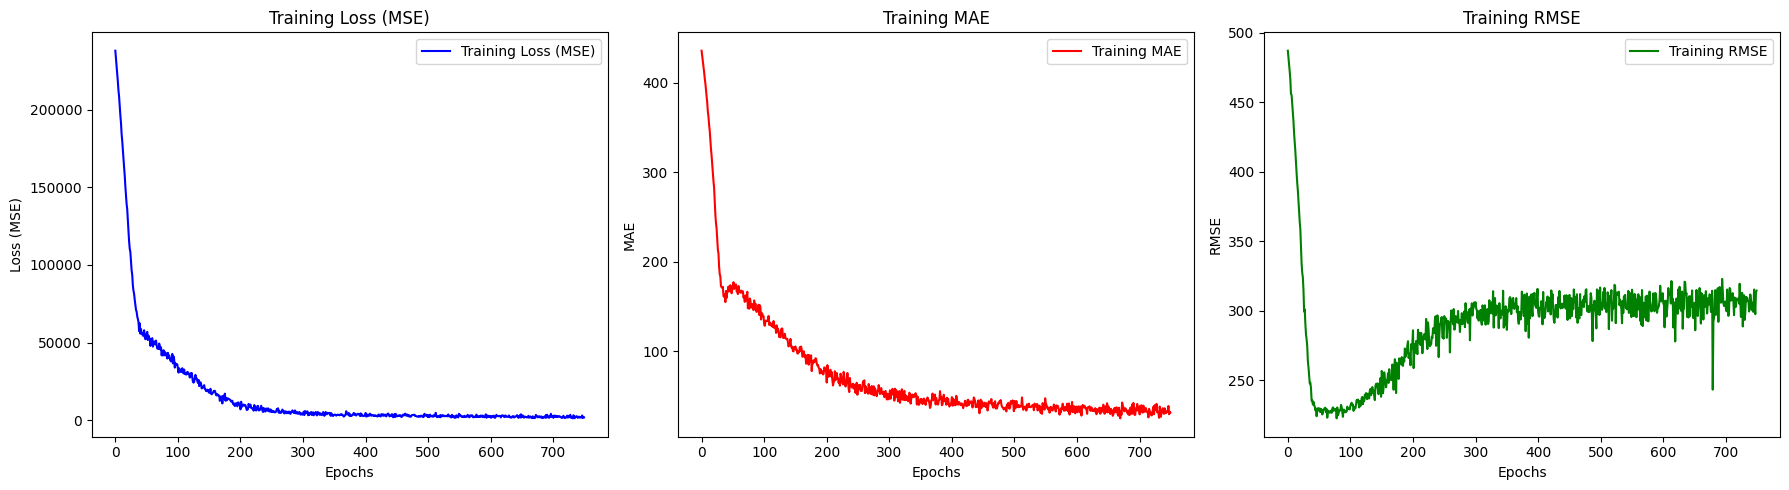

In [ ]:
plt.figure(figsize=(18, 5))

# Plot Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss (MSE)')
plt.legend()

# Plot Mean Absolute Error (MAE)
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', color='red')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training MAE')
plt.legend()

# Plot Root Mean Squared Error (RMSE)
plt.subplot(1, 3, 3)
plt.plot(history.history['rmse'], label='Training RMSE', color='green')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training RMSE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Ambil nilai MAE dan RMSE dari history
mae_values = history.history['mae']
rmse_values = history.history['rmse']

min_mae_index = mae_values.index(min(mae_values))

min_mae = mae_values[min_mae_index]
corresponding_rmse = rmse_values[min_mae_index]

print(f"MAE terkecil: {min_mae:.4f} pada epoch {min_mae_index + 1}")
print(f"RMSE pada epoch yang sama: {corresponding_rmse:.4f}")


MAE terkecil: 25.1526 pada epoch 670
RMSE pada epoch yang sama: 304.9407
